### Newton–Raphson Method

The **Newton–Raphson Method** is a fast iterative technique for finding the root of
$$
f(x) = 0
$$
Starting from an initial guess \\(x_0\\), the method uses the tangent line at each point to produce a better estimate
$$
x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}
$$

This process is repeated until the function value at \\(x_n\\) is sufficiently close to zero, or the change between successive iterates is small.

The Newton–Raphson method converges **quadratically** near a simple root, making it much faster than the bisection method, but it requires the derivative \\(f'(x)\\) and is **not guaranteed to converge** for poor initial guesses.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def f(x):
    return x**3 - x - 2

def df(x):
    return 3*x**2 - 1


In [3]:
def newton_raphson_table(f, df, x0, tol=1e-6, max_iter=100):
    print(f"{'n':>2} {'x':>12} {'f(x)':>14} {'error':>14}")
    print("-" * 50)

    x = x0
    for n in range(1, max_iter + 1):
        fx = f(x)
        dfx = df(x)
        if dfx == 0:
            raise ZeroDivisionError("Derivative is zero")

        x_new = x - fx / dfx
        error = abs(x_new - x)

        print(f"{n:2d} {x_new:12.6f} {f(x_new):14.6e} {error:14.6e}")

        if error < tol or abs(f(x_new)) < tol:
            print(f"\nConverged in {n} iterations")
            return x_new

        x = x_new

    raise RuntimeError("Maximum iterations reached")


In [4]:
root = newton_raphson_table(f, df, x0=1.5)
print("Root =", root)


 n            x           f(x)          error
--------------------------------------------------
 1     1.521739   2.136928e-03   2.173913e-02
 2     1.521380   5.893874e-07   3.593245e-04

Converged in 2 iterations
Root = 1.5213798059647863


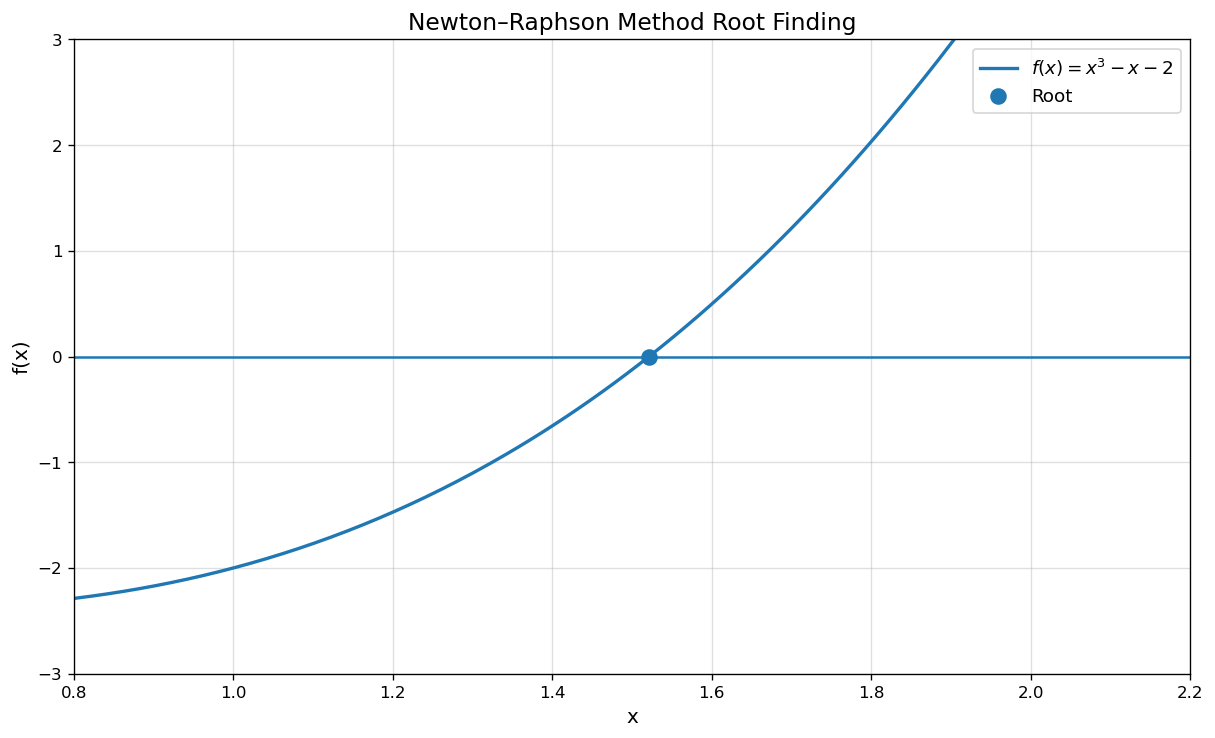

In [5]:
plt.figure(figsize=(12, 7), dpi=120)

# Axes lines (Desmos-style)
plt.axhline(0)
plt.axvline(0)

x = np.linspace(0, 2.5, 500)
y = f(x)

# Function
plt.plot(x, y, linewidth=2, label=r"$f(x)=x^3-x-2$")

# Root marker
plt.scatter(root, f(root), s=80, zorder=5, label="Root")

# Zoom near root
plt.xlim(0.8, 2.2)
plt.ylim(-3, 3)

# Grid like Desmos
plt.grid(True, alpha=0.4)

# Labels
plt.xlabel("x", fontsize=12)
plt.ylabel("f(x)", fontsize=12)
plt.title("Newton\u2013Raphson Method Root Finding", fontsize=14)

plt.legend(fontsize=11)
plt.show()
